In [5]:
#IMPORTING ALL LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import os

# Import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report, roc_curve, auc
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")


All libraries imported successfully!


In [39]:
# Set styling for better visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)
%matplotlib inline
warnings.filterwarnings('ignore')

In [ ]:
# Pima Indians Diabetes Dataset
#Load Dataset
df = pd.read_csv("../data/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [41]:
# Check dataset shape
print(f"Dataset shape: {df.shape}")
print(f"Number of samples: {df.shape[0]}")
print(f"Number of features: {df.shape[1] -1 } (plus Outcome target variable)")

Dataset shape: (768, 9)
Number of samples: 768
Number of features: 8 (plus Outcome target variable)


In [42]:
# Summary statistics
print("Summary statistics:")
df.describe()

Summary statistics:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [43]:
# Check for class balance
print("Class distribution (0 = Non-diabetic, 1 = Diabetic):")
print(df['Outcome'].value_counts())
print(f"\nPercentage of Non-diabetic: {df['Outcome'].value_counts()[0]/len(df)*100:.2f}%")
print(f"Percentage of Diabetic: {df['Outcome'].value_counts()[1]/len(df)*100:.2f}%")

Class distribution (0 = Non-diabetic, 1 = Diabetic):
Outcome
0    500
1    268
Name: count, dtype: int64

Percentage of Non-diabetic: 65.10%
Percentage of Diabetic: 34.90%


In [44]:

print("\n" + "="*50)
print("STEP 2: Features Correlated with Diabetes Outcome")
print("="*50)
correlation_matrix = df.corr()
# Get correlation with Outcome only
correlation_with_outcome = correlation_matrix['Outcome'].sort_values(ascending=False)

print("\n📊 How each feature correlates with diabetes:")
print("-" * 40)
for feature, corr in correlation_with_outcome.items():
    if feature != 'Outcome':  # Don't show Outcome correlated with itself
        # Add emoji indicator
        if abs(corr) >= 0.5:
            indicator = "🔴 STRONG"
        elif abs(corr) >= 0.3:
            indicator = "🟡 MODERATE"
        else:
            indicator = "🟢 WEAK"
        
        # Show direction
        if corr > 0:
            direction = "positive (higher → more diabetes)"
        else:
            direction = "negative (higher → less diabetes)"
            
        print(f"{feature:25} {corr:+.3f}  |  {indicator}  |  {direction}")


STEP 2: Features Correlated with Diabetes Outcome

📊 How each feature correlates with diabetes:
----------------------------------------
Glucose                   +0.467  |  🟡 MODERATE  |  positive (higher → more diabetes)
BMI                       +0.293  |  🟢 WEAK  |  positive (higher → more diabetes)
Age                       +0.238  |  🟢 WEAK  |  positive (higher → more diabetes)
Pregnancies               +0.222  |  🟢 WEAK  |  positive (higher → more diabetes)
DiabetesPedigreeFunction  +0.174  |  🟢 WEAK  |  positive (higher → more diabetes)
Insulin                   +0.131  |  🟢 WEAK  |  positive (higher → more diabetes)
SkinThickness             +0.075  |  🟢 WEAK  |  positive (higher → more diabetes)
BloodPressure             +0.065  |  🟢 WEAK  |  positive (higher → more diabetes)



Creating Correlation Heatmap


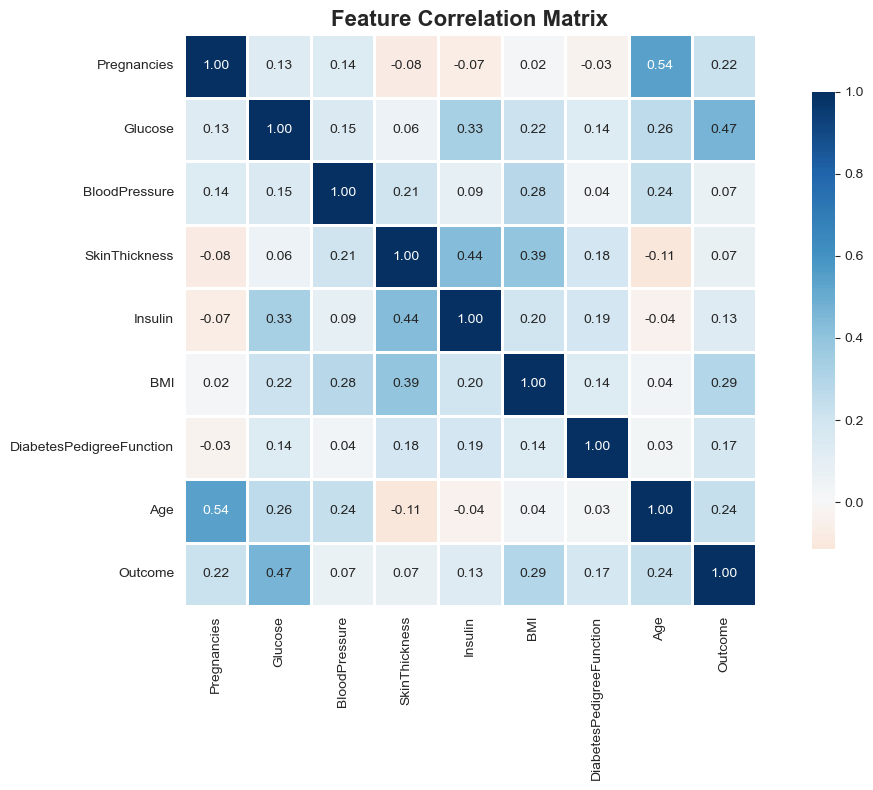


 Heatmap created!


In [45]:
#CORRELATION ANALYSIS
print("\n" + "="*50)
print("Creating Correlation Heatmap")
print("="*50)


plt.figure(figsize=(12, 8))

# Create heatmap
sns.heatmap(correlation_matrix, 
            annot=True,           # Show numbers in each cell
            cmap='RdBu',       # Red-blue color scheme
            center=0,              # Center color map at 0
            square=True,           # Make cells square
            linewidths=1,           # Lines between cells
            cbar_kws={"shrink": 0.8},  # Make color bar smaller
            fmt='.2f',              # Show 2 decimal places
            annot_kws={'size': 10})  # Font size for numbers

plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n Heatmap created!")


 Enhanced Box Plots with Data Points


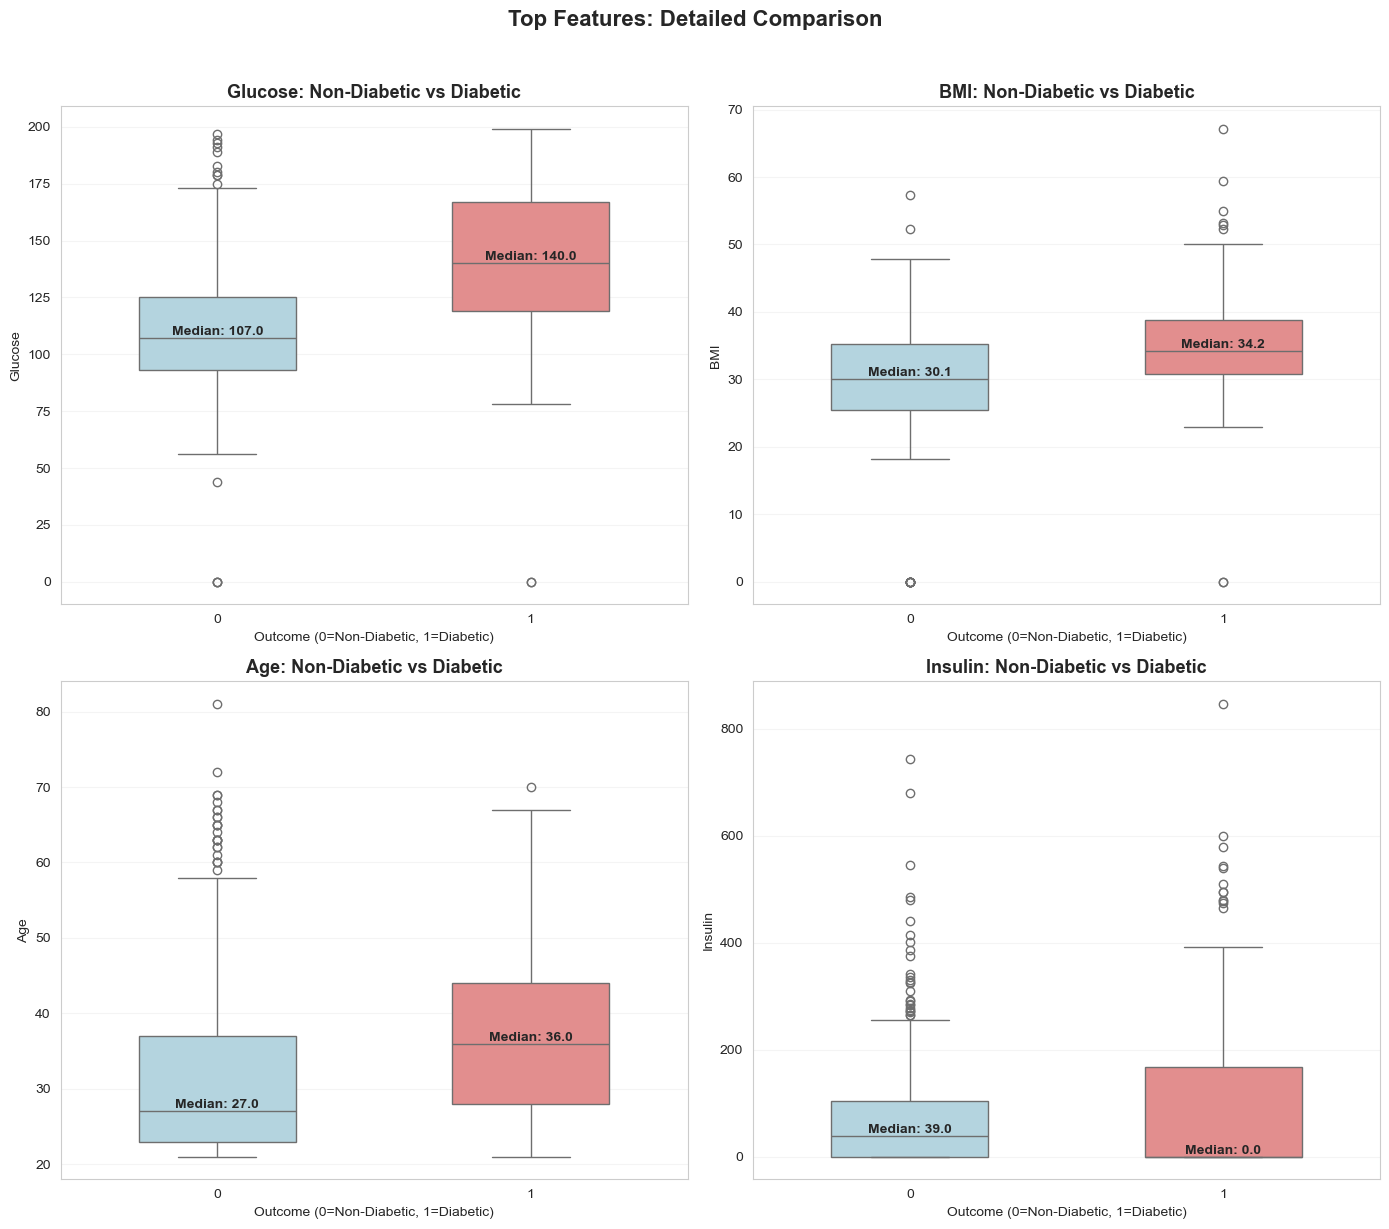

In [46]:

print("\n" + "="*50)
print(" Enhanced Box Plots with Data Points")
print("="*50)

# Pick the 4 most important features (based on correlation we found)
top_features = ['Glucose', 'BMI', 'Age', 'Insulin']

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, feature in enumerate(top_features):
    # Box plot
    sns.boxplot(x='Outcome', y=feature, data=df, ax=axes[idx], 
                palette=['lightblue', 'lightcoral'], width=0.5)
    
   
    
    
    axes[idx].set_title(f'{feature}: Non-Diabetic vs Diabetic', fontweight='bold', fontsize=13)
    axes[idx].set_xlabel('Outcome (0=Non-Diabetic, 1=Diabetic)')
    axes[idx].set_ylabel(feature)
    axes[idx].grid(axis='y', alpha=0.2)
    
    # Add median values
    medians = df.groupby('Outcome')[feature].median()
    axes[idx].text(0, medians[0], f'Median: {medians[0]:.1f}', 
                   ha='center', va='bottom', fontweight='bold', fontsize=10)
    axes[idx].text(1, medians[1], f'Median: {medians[1]:.1f}', 
                   ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.suptitle('Top Features: Detailed Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


SIMPLER VIEW: Top 3 Features


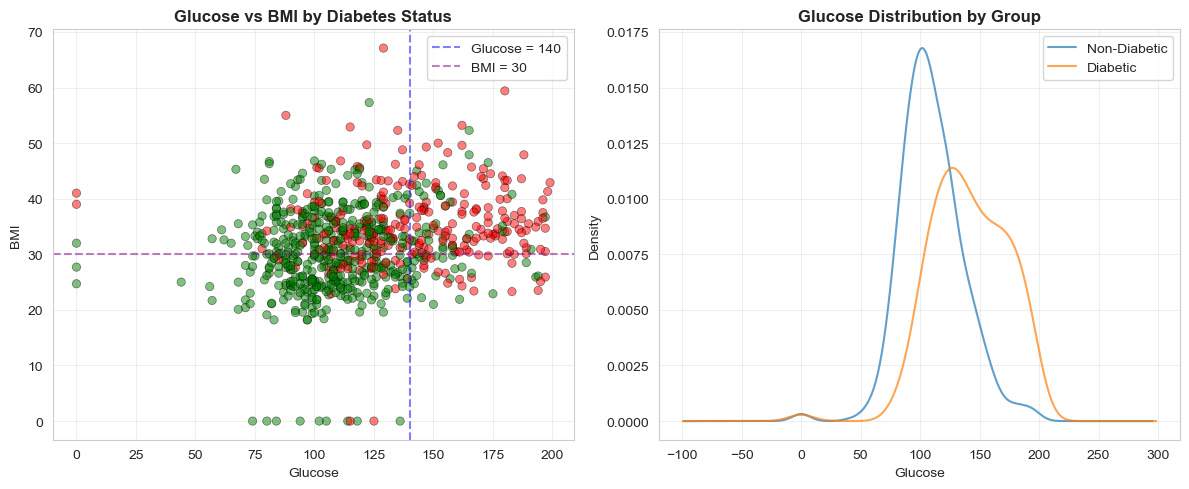


📌 Notice how:
• Most diabetic patients (red) have glucose > 140
• Many also have BMI > 30
• But there are exceptions in both directions!


In [47]:
# ============================================
# 3.5 SIMPLER VIEW - SCATTER MATRIX
# ============================================

print("\n" + "="*50)
print("SIMPLER VIEW: Top 3 Features")
print("="*50)

# Just 3 features + outcome
simple_features = ['Glucose', 'BMI', 'Outcome']

plt.figure(figsize=(12, 5))

# Scatter plot: Glucose vs BMI colored by Outcome
plt.subplot(1, 2, 1)
colors = ['green' if x == 0 else 'red' for x in df['Outcome']]
plt.scatter(df['Glucose'], df['BMI'], c=colors, alpha=0.5, edgecolors='black', linewidth=0.5)
plt.xlabel('Glucose')
plt.ylabel('BMI')
plt.title('Glucose vs BMI by Diabetes Status', fontweight='bold')
plt.grid(True, alpha=0.3)

# Add a simple dividing line (example threshold)
plt.axvline(x=140, color='blue', linestyle='--', alpha=0.5, label='Glucose = 140')
plt.axhline(y=30, color='purple', linestyle='--', alpha=0.5, label='BMI = 30')
plt.legend()

# Distribution comparison
plt.subplot(1, 2, 2)
df.groupby('Outcome')['Glucose'].plot(kind='kde', alpha=0.7)
plt.xlabel('Glucose')
plt.title('Glucose Distribution by Group', fontweight='bold')
plt.legend(['Non-Diabetic', 'Diabetic'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📌 Notice how:")
print("• Most diabetic patients (red) have glucose > 140")
print("• Many also have BMI > 30")
print("• But there are exceptions in both directions!")


4.1 HANDLE MISSING VALUES

 Checking for zeros in medical measurements:
--------------------------------------------------
Glucose              :    5 zeros (  0.7%)
BloodPressure        :   35 zeros (  4.6%)
SkinThickness        :  227 zeros ( 29.6%)
Insulin              :  374 zeros ( 48.7%)
BMI                  :   11 zeros (  1.4%)


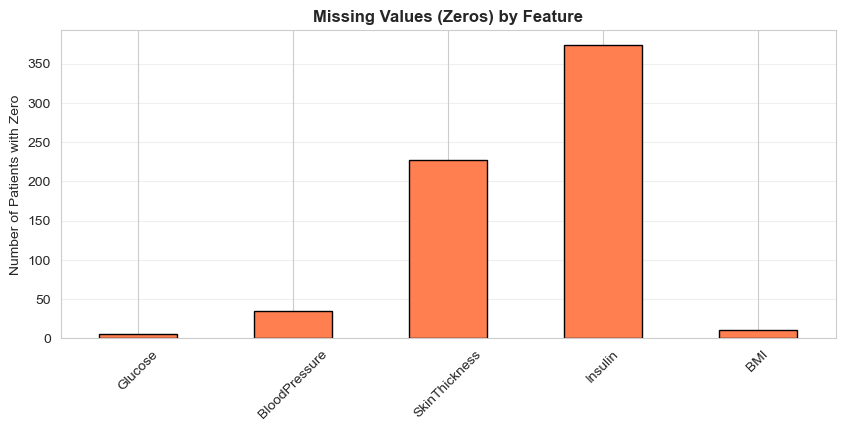

In [48]:

print("\n" + "="*60)
print("4.1 HANDLE MISSING VALUES")
print("="*60)

# Columns where zero is not possible
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

plt.show()
print("\n Checking for zeros in medical measurements:")
print("-" * 50)
for col in columns_with_zeros:
    zeros = (df[col] == 0).sum()
    percentage = (zeros/len(df)) * 100
    print(f"{col:20} : {zeros:4} zeros ({percentage:5.1f}%)")

# Visualize the missing data problem
plt.figure(figsize=(10, 4))
missing_data = (df[columns_with_zeros] == 0).sum()
missing_data.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Missing Values (Zeros) by Feature', fontweight='bold')
plt.ylabel('Number of Patients with Zero')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)


In [49]:

# Replace zeros with NaN in columns where zero is invalid
for i in columns_with_zeros:
    df[i] = df[i].replace(0, np.nan)

print("After replacing zeros with NaN:")
df.isnull().sum()

After replacing zeros with NaN:


Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [50]:
#Handle Missing Values

for i in columns_with_zeros:
    median_val = df[i].median()
    df[i].fillna(median_val, inplace=True)
    print(f"{i} filled with median: {median_val:.2f}")

# Verify no missing values remain
print(f"\nRemaining missing values: {df.isnull().sum().sum()}")

Glucose filled with median: 117.00
BloodPressure filled with median: 72.00
SkinThickness filled with median: 29.00
Insulin filled with median: 125.00
BMI filled with median: 32.30

Remaining missing values: 0



 Checking for zeros in medical measurements:
--------------------------------------------------
Glucose              :    0 zeros (  0.0%)
BloodPressure        :    0 zeros (  0.0%)
SkinThickness        :    0 zeros (  0.0%)
Insulin              :    0 zeros (  0.0%)
BMI                  :    0 zeros (  0.0%)


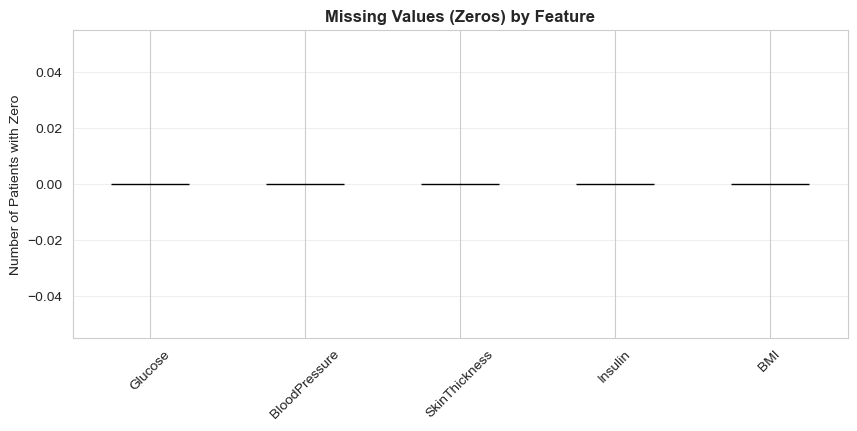

In [51]:
columns_with_zeros = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

plt.show()
print("\n Checking for zeros in medical measurements:")
print("-" * 50)
for col in columns_with_zeros:
    zeros = (df[col] == 0).sum()
    percentage = (zeros/len(df)) * 100
    print(f"{col:20} : {zeros:4} zeros ({percentage:5.1f}%)")

# Visualize the missing data problem
plt.figure(figsize=(10, 4))
missing_data = (df[columns_with_zeros] == 0).sum()
missing_data.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Missing Values (Zeros) by Feature', fontweight='bold')
plt.ylabel('Number of Patients with Zero')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)


In [52]:
# Separate features (X) and target (y)
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [53]:
# Initialize scaler
scaler = StandardScaler()
# Fit and transform the features
X_scaled = scaler.fit_transform(X)

In [54]:
# Convert back to DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("Features after scaling:")
X_scaled.describe().T

Features after scaling:


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,-6.476301e-17,1.000652,-1.141852,-0.844885,-0.250952,0.639947,3.906578
Glucose,768.0,4.625929e-18,1.000652,-2.552931,-0.720163,-0.153073,0.611265,2.542658
BloodPressure,768.0,5.782412e-18,1.000652,-4.002619,-0.693761,-0.031990,0.629782,4.104082
SkinThickness,768.0,-1.526557e-16,1.000652,-2.516429,-0.467597,-0.012301,0.329171,7.955377
Insulin,768.0,1.503427e-17,1.000652,-1.467353,-0.222085,-0.181541,-0.155477,8.170442
BMI,768.0,2.613650e-16,1.000652,-2.074783,-0.721209,-0.022590,0.603256,5.042397
DiabetesPedigreeFunction,768.0,2.451743e-16,1.000652,-1.189553,-0.688969,-0.300128,0.466227,5.883565
Age,768.0,1.931325e-16,1.000652,-1.041549,-0.786286,-0.360847,0.660206,4.063716


In [55]:
#Train-Test Split

# Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")

Training set size: 614 samples
Test set size: 154 samples


In [56]:
print(f"\nTraining set class distribution:")
print(y_train.value_counts(normalize=True))
print(f"\nTest set class distribution:")
print(y_test.value_counts(normalize=True))


Training set class distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Test set class distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [57]:
# ============================================
# HELPER FUNCTION FOR MODEL EVALUATION (CORRECTED)
# ============================================

print("="*60)
print("CREATING HELPER FUNCTION - USING EXISTING DATA")
print("="*60)

def evaluate_model(model, y_pred_train, y_pred_test, model_name):
    """
    
    
    Parameters:
    model: the trained machine learning model (optional, for reference)
    y_pred_train: predictions on training data (already made)
    y_pred_test: predictions on test data (already made)
    model_name: string name of the model
    
    Returns:
    metrics: dictionary of performance metrics
    cm: confusion matrix
    """
    
    print(f"\n{'='*50}")
    print(f"Evaluating: {model_name}")
    print(f"{'='*50}")
    
    # Step 1: Calculate metrics
    print("📝 Calculating metrics...")
    
    # Accuracy (using global y_train and y_test)
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc = accuracy_score(y_test, y_pred_test)
    
    # Precision, Recall, F1
    precision = precision_score(y_test, y_pred_test)
    recall = recall_score(y_test, y_pred_test)
    f1 = f1_score(y_test, y_pred_test)
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_test)
    
    # Store metrics
    metrics = {
        'Model': model_name,
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }
    
    # Display results
    print(f"\n📊 Results for {model_name}:")
    print("-" * 50)
    print(f"Train Accuracy: {train_acc:.4f} ({train_acc*100:.2f}%)")
    print(f"Test Accuracy:  {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(f"Precision:      {precision:.4f}")
    print(f"Recall:         {recall:.4f}")
    print(f"F1 Score:       {f1:.4f}")
    
    print(f"\nConfusion Matrix:")
    print(f"               Predicted")
    print(f"               Neg  Pos")
    print(f"Actual Neg     {cm[0,0]:3}  {cm[0,1]:3}")
    print(f"       Pos     {cm[1,0]:3}  {cm[1,1]:3}")
    
    return metrics, cm


print("\n✅ Helper function created successfully!")
print("\n📌 This function uses the global data:")
print(f"   • X_train: {X_train.shape}")
print(f"   • X_test: {X_test.shape}")
print(f"   • y_train: {y_train.shape}")
print(f"   • y_test: {y_test.shape}")

CREATING HELPER FUNCTION - USING EXISTING DATA

✅ Helper function created successfully!

📌 This function uses the global data:
   • X_train: (614, 8)
   • X_test: (154, 8)
   • y_train: (614,)
   • y_test: (154,)


In [58]:
#Logistic Regression

print("\n📝 Step 1: Training model...")
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
print("✅ Model trained!")




📝 Step 1: Training model...
✅ Model trained!


In [59]:
print("\n📝 Step 2: Making predictions...")
y_pred_train_lr = lr_model.predict(X_train)
y_pred_test_lr = lr_model.predict(X_test)
print("✅ Predictions made!")


📝 Step 2: Making predictions...
✅ Predictions made!


In [60]:
lr_metrics, lr_cm = evaluate_model(
    lr_model,                    # model (optional)
    y_pred_train_lr,             # training predictions
    y_pred_test_lr,              # test predictions
    "Logistic Regression"         # model name
)



Evaluating: Logistic Regression
📝 Calculating metrics...

📊 Results for Logistic Regression:
--------------------------------------------------
Train Accuracy: 0.7964 (79.64%)
Test Accuracy:  0.7013 (70.13%)
Precision:      0.5870
Recall:         0.5000
F1 Score:       0.5400

Confusion Matrix:
               Predicted
               Neg  Pos
Actual Neg      81   19
       Pos      27   27


In [61]:

## Decision Tree
#Creating Decision Tree model...

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,     # For reproducible results
    max_depth=5,         # Limit how deep the tree grows
    min_samples_split=10 # Minimum samples to split a node
)

In [62]:
# Train the model
dt_model.fit(X_train, y_train)

print("✅ Training complete!")
print(f"   • Trained on {X_train.shape[0]} patients")
print(f"   • Using {X_train.shape[1]} features")

✅ Training complete!
   • Trained on 614 patients
   • Using 8 features


In [63]:
# Predict on training data
y_pred_train_dt = dt_model.predict(X_train)

# Predict on test data
y_pred_test_dt = dt_model.predict(X_test)

print("✅ Predictions made!")
print(f"   • Training predictions: {len(y_pred_train_dt)}")
print(f"   • Test predictions: {len(y_pred_test_dt)}")

# Show first 10 predictions
print("\n First 10 test predictions:")
print("-" * 40)
print(f"Actual:    {y_test.values[:10]}")
print(f"Predicted: {y_pred_test_dt[:10]}")
print("-" * 40)


✅ Predictions made!
   • Training predictions: 614
   • Test predictions: 154

 First 10 test predictions:
----------------------------------------
Actual:    [0 0 0 1 0 0 1 1 0 0]
Predicted: [1 0 0 1 0 0 0 1 0 1]
----------------------------------------


In [64]:
dt_metrics, dt_cm = evaluate_model(
    dt_model,                 # The trained model
    y_pred_train_dt,          # Training predictions
    y_pred_test_dt,           # Test predictions
    "Decision Tree"           # Model name
)

print("\n✅ Evaluation complete!")



Evaluating: Decision Tree
📝 Calculating metrics...

📊 Results for Decision Tree:
--------------------------------------------------
Train Accuracy: 0.8127 (81.27%)
Test Accuracy:  0.7662 (76.62%)
Precision:      0.6500
Recall:         0.7222
F1 Score:       0.6842

Confusion Matrix:
               Predicted
               Neg  Pos
Actual Neg      79   21
       Pos      15   39

✅ Evaluation complete!


In [65]:

#Support Vector Machine

svm_model = SVC(random_state=42, probability=True)
print("\n Step 2: Training SVM...")
svm_model.fit(X_train, y_train)
print(" Training complete")

# STEP 3: Make predictions
print("\n Step 3: Making predictions...")
y_pred_train_svm = svm_model.predict(X_train)
y_pred_test_svm = svm_model.predict(X_test)
print(" Predictions made")


 Step 2: Training SVM...
 Training complete

 Step 3: Making predictions...
 Predictions made


In [66]:
# STEP 4: Evaluate using helper function
print("\n Step 4: Evaluating SVM...")
svm_metrics, svm_cm = evaluate_model(
    svm_model,
    y_pred_train_svm,
    y_pred_test_svm,
    "SVM"
)
print(" SVM evaluation complete")


 Step 4: Evaluating SVM...

Evaluating: SVM
📝 Calculating metrics...

📊 Results for SVM:
--------------------------------------------------
Train Accuracy: 0.8404 (84.04%)
Test Accuracy:  0.7338 (73.38%)
Precision:      0.6444
Recall:         0.5370
F1 Score:       0.5859

Confusion Matrix:
               Predicted
               Neg  Pos
Actual Neg      84   16
       Pos      25   29
 SVM evaluation complete


In [67]:
#Random Forest
print("\n Creating Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    max_depth=5
)
print(" Model created")

# Train
print("\n📝 Training...")
rf_model.fit(X_train, y_train)
print(" Training complete")

# Predict
print("\n Predicting...")
y_pred_train_rf = rf_model.predict(X_train)
y_pred_test_rf = rf_model.predict(X_test)
print(" Predictions made")



 Creating Random Forest...
 Model created

📝 Training...
 Training complete

 Predicting...
 Predictions made


In [68]:
print("\n Evaluating...")
rf_metrics, rf_cm = evaluate_model(
    rf_model,
    y_pred_train_rf,
    y_pred_test_rf,
    "Random Forest"
)


 Evaluating...

Evaluating: Random Forest
📝 Calculating metrics...

📊 Results for Random Forest:
--------------------------------------------------
Train Accuracy: 0.8485 (84.85%)
Test Accuracy:  0.7403 (74.03%)
Precision:      0.6667
Recall:         0.5185
F1 Score:       0.5833

Confusion Matrix:
               Predicted
               Neg  Pos
Actual Neg      86   14
       Pos      26   28


In [69]:
#Model Comparison
# ============================================
# SECTION 6: MODEL COMPARISON
# ============================================

print("="*70)
print("📊 SECTION 6: MODEL COMPARISON")
print("="*70)

# Create comprehensive comparison dataframe
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'SVM', 'Random Forest'],
    'Train Accuracy': [
        lr_metrics['Train Accuracy'],
        dt_metrics['Train Accuracy'],
        svm_metrics['Train Accuracy'],
        rf_metrics['Train Accuracy']
    ],
    'Test Accuracy': [
        lr_metrics['Test Accuracy'],
        dt_metrics['Test Accuracy'],
        svm_metrics['Test Accuracy'],
        rf_metrics['Test Accuracy']
    ],
    'Precision': [
        lr_metrics['Precision'],
        dt_metrics['Precision'],
        svm_metrics['Precision'],
        rf_metrics['Precision']
    ],
    'Recall': [
        lr_metrics['Recall'],
        dt_metrics['Recall'],
        svm_metrics['Recall'],
        rf_metrics['Recall']
    ],
    'F1 Score': [
        lr_metrics['F1 Score'],
        dt_metrics['F1 Score'],
        svm_metrics['F1 Score'],
        rf_metrics['F1 Score']
    ]
})

# Add overfitting measure (Train - Test)
comparison['Overfitting'] = comparison['Train Accuracy'] - comparison['Test Accuracy']

print("\n📋 COMPLETE MODEL COMPARISON TABLE:")
print("-" * 80)
print(comparison.round(4).to_string(index=False))


📊 SECTION 6: MODEL COMPARISON

📋 COMPLETE MODEL COMPARISON TABLE:
--------------------------------------------------------------------------------
              Model  Train Accuracy  Test Accuracy  Precision  Recall  F1 Score  Overfitting
Logistic Regression          0.7964         0.7013     0.5870  0.5000    0.5400       0.0951
      Decision Tree          0.8127         0.7662     0.6500  0.7222    0.6842       0.0465
                SVM          0.8404         0.7338     0.6444  0.5370    0.5859       0.1066
      Random Forest          0.8485         0.7403     0.6667  0.5185    0.5833       0.1083


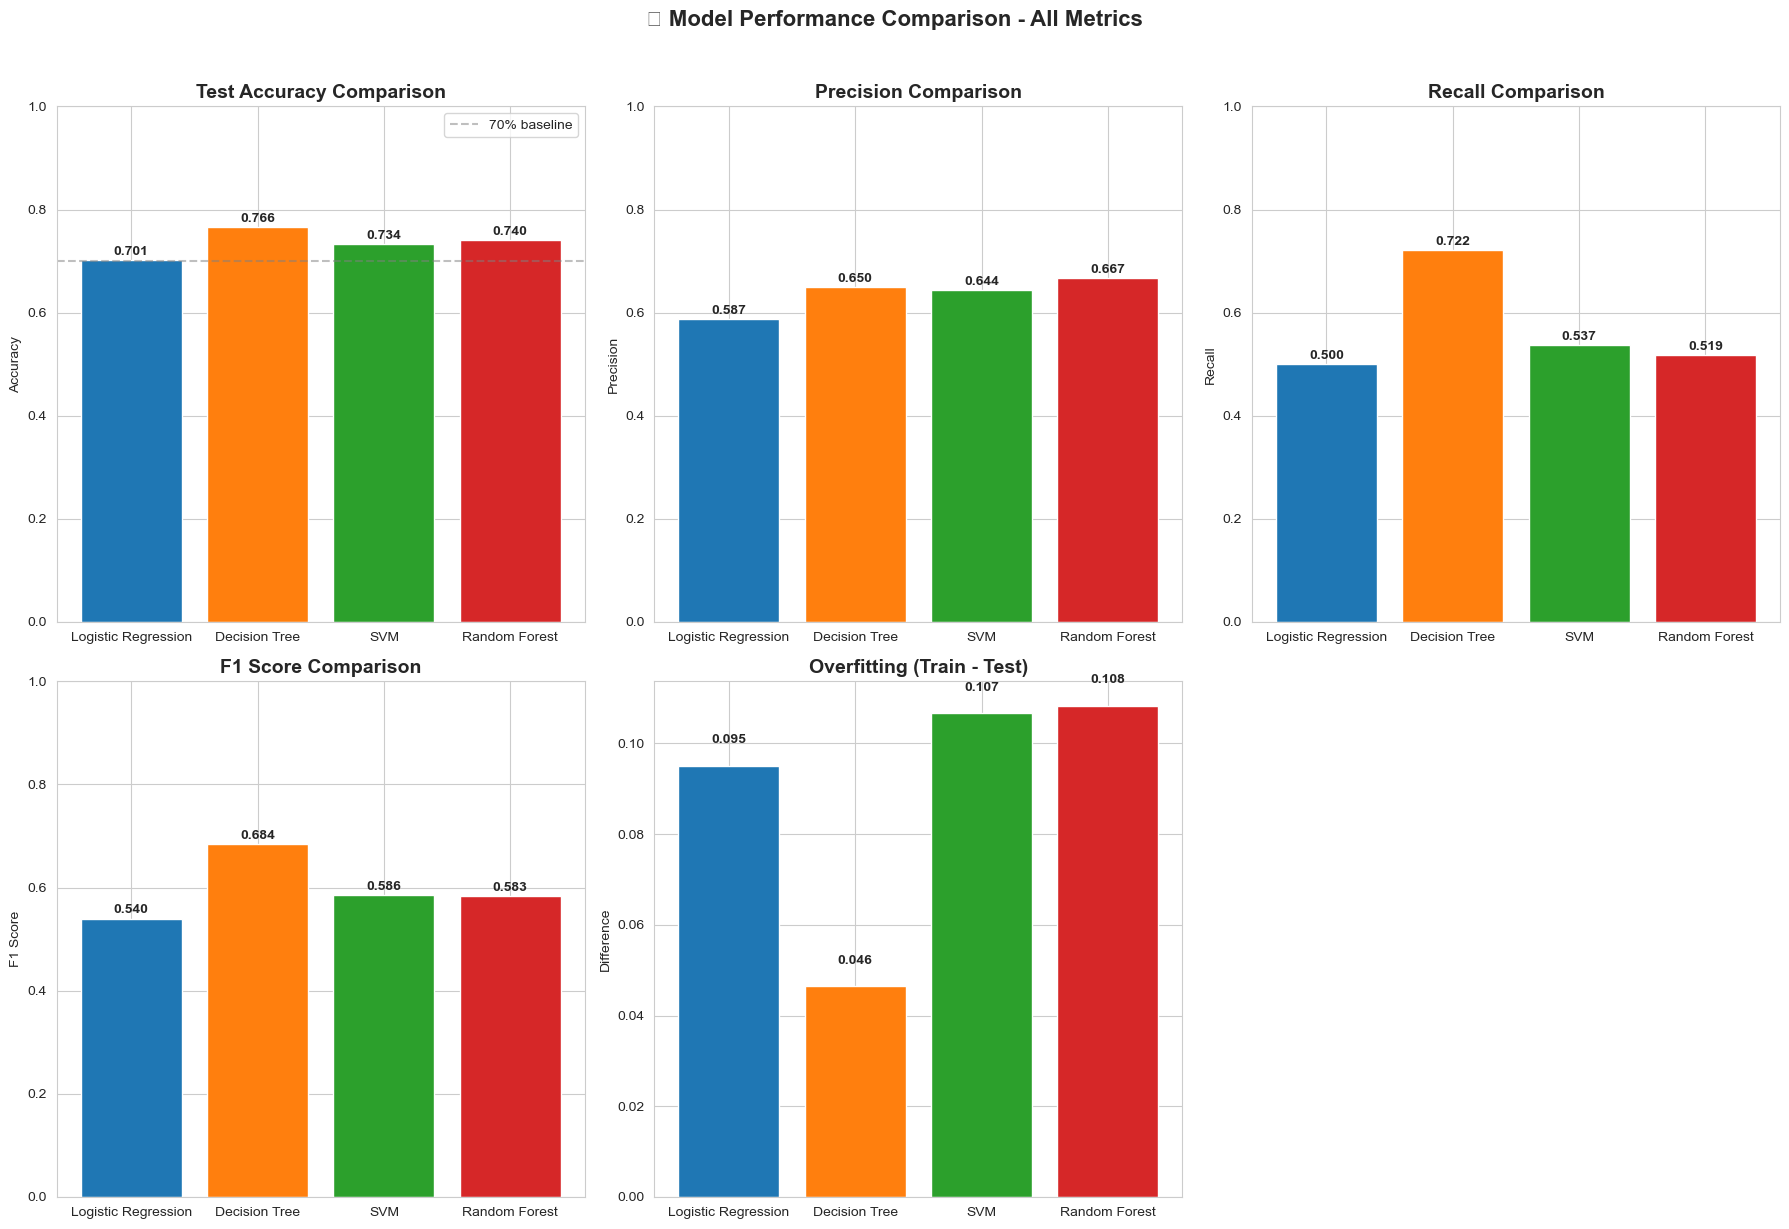

In [70]:
#Visual Comparison

# ============================================
# VISUAL COMPARISON - BAR CHARTS
# ============================================


# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 10)

# Create figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# 1. Test Accuracy Comparison
ax1 = axes[0]
bars1 = ax1.bar(comparison['Model'], comparison['Test Accuracy'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax1.set_title('Test Accuracy Comparison', fontsize=14, fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1)
ax1.axhline(y=0.7, color='gray', linestyle='--', alpha=0.5, label='70% baseline')
for bar, val in zip(bars1, comparison['Test Accuracy']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')
ax1.legend()

# 2. Precision Comparison
ax2 = axes[1]
bars2 = ax2.bar(comparison['Model'], comparison['Precision'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax2.set_title('Precision Comparison', fontsize=14, fontweight='bold')
ax2.set_ylabel('Precision')
ax2.set_ylim(0, 1)
for bar, val in zip(bars2, comparison['Precision']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')

# 3. Recall Comparison
ax3 = axes[2]
bars3 = ax3.bar(comparison['Model'], comparison['Recall'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax3.set_title('Recall Comparison', fontsize=14, fontweight='bold')
ax3.set_ylabel('Recall')
ax3.set_ylim(0, 1)
for bar, val in zip(bars3, comparison['Recall']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')

# 4. F1 Score Comparison
ax4 = axes[3]
bars4 = ax4.bar(comparison['Model'], comparison['F1 Score'], 
                color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax4.set_title('F1 Score Comparison', fontsize=14, fontweight='bold')
ax4.set_ylabel('F1 Score')
ax4.set_ylim(0, 1)
for bar, val in zip(bars4, comparison['F1 Score']):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontweight='bold')

# 5. Overfitting Comparison
ax5 = axes[4]
bars5 = ax5.bar(comparison['Model'], comparison['Overfitting'], 
                 color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax5.set_title('Overfitting (Train - Test)', fontsize=14, fontweight='bold')
ax5.set_ylabel('Difference')
ax5.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
for bar, val in zip(bars5, comparison['Overfitting']):
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', fontweight='bold')

# 6. Radar Chart placeholder or hide
axes[5].set_visible(False)

plt.suptitle('📊 Model Performance Comparison - All Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

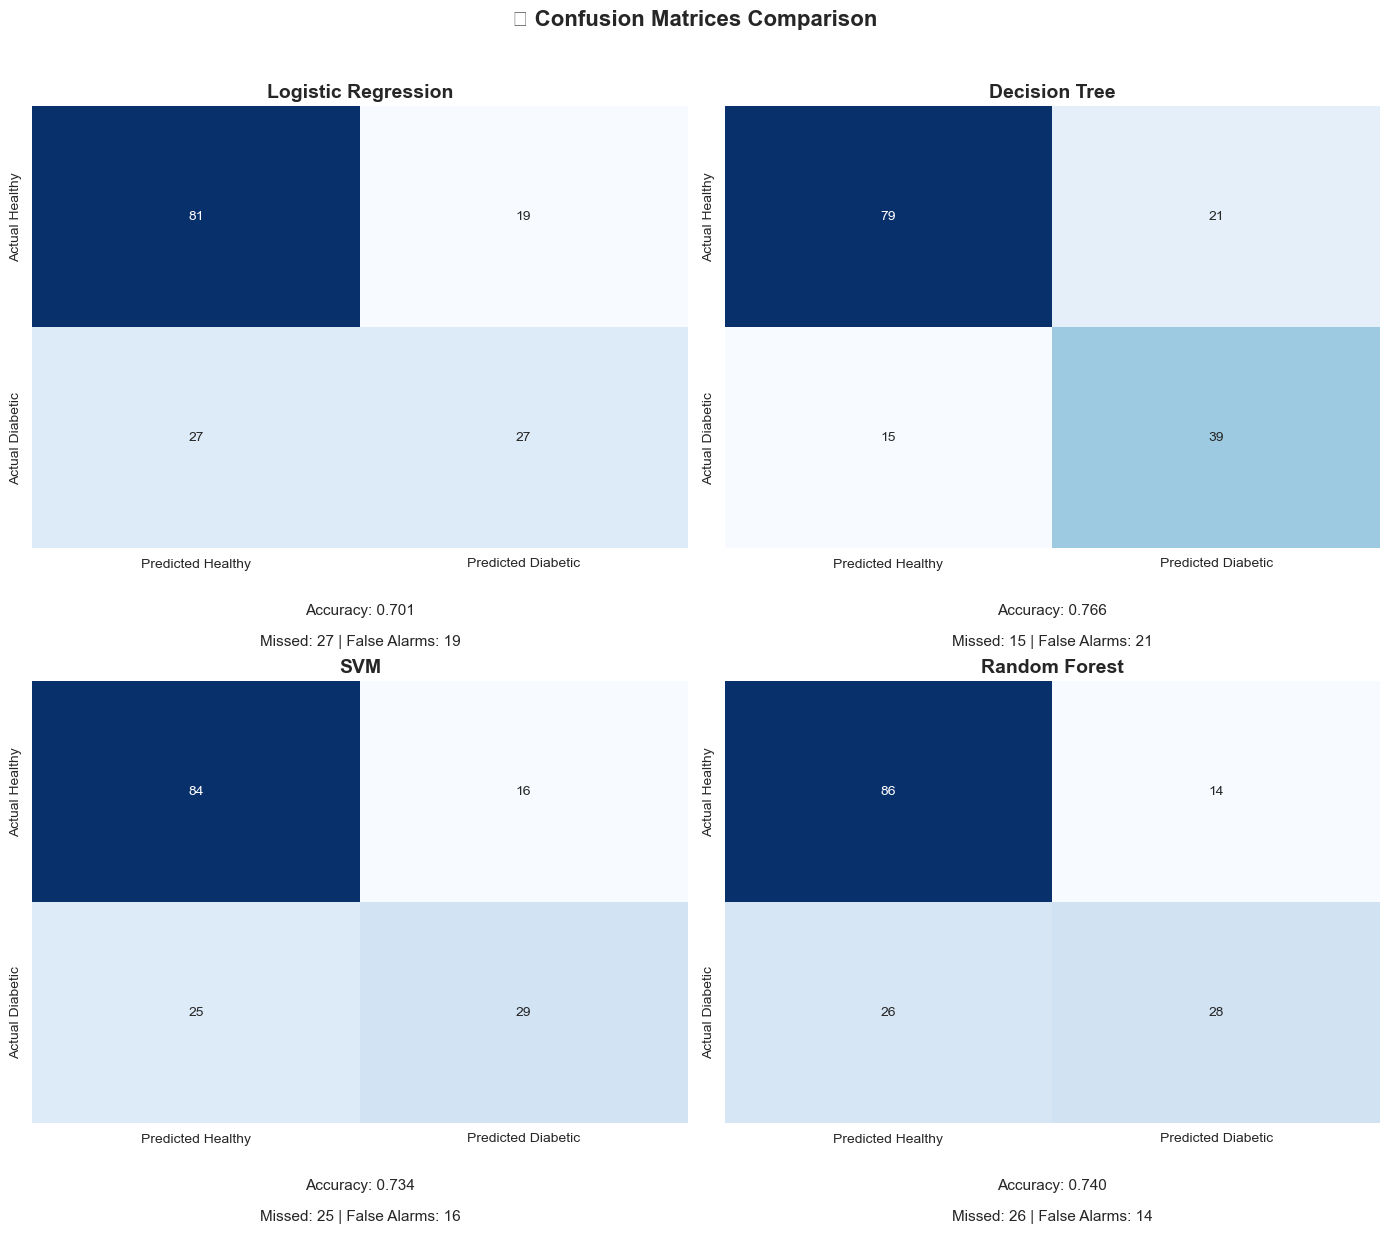

In [71]:
#Confusion Matrix Visualization
# ============================================
# CONFUSION MATRICES - ALL MODELS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

# Collect all confusion matrices and model names
confusion_data = [
    (lr_cm, "Logistic Regression"),
    (dt_cm, "Decision Tree"),
    (svm_cm, "SVM"),
    (rf_cm, "Random Forest")
]

for idx, (cm, name) in enumerate(confusion_data):
    tn, fp, fn, tp = cm.ravel()
    
    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Predicted Healthy', 'Predicted Diabetic'],
                yticklabels=['Actual Healthy', 'Actual Diabetic'],
                cbar=False)
    
    axes[idx].set_title(f'{name}', fontweight='bold', fontsize=14)
    
    # Add metrics as text
    accuracy = (tn + tp) / (tn + fp + fn + tp)
    axes[idx].text(0.5, -0.15, f'Accuracy: {accuracy:.3f}', 
                   transform=axes[idx].transAxes, ha='center', fontsize=11)
    axes[idx].text(0.5, -0.22, f'Missed: {fn} | False Alarms: {fp}', 
                   transform=axes[idx].transAxes, ha='center', fontsize=11)

plt.suptitle('🔍 Confusion Matrices Comparison', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


In [72]:
# ============================================
# FINAL MODEL SELECTION
# ============================================

print("\n" + "="*70)
print("🏆 FINAL VERDICT: BEST MODEL FOR DIABETES PREDICTION")
print("="*70)

# Calculate overall score (weighted for medical context)
# Recall is weighted more because missing diabetics is worse
comparison['Medical_Score'] = (
    comparison['Recall'] * 0.5 +      # 50% weight - catching diabetics
    comparison['Precision'] * 0.3 +    # 30% weight - avoiding false alarms
    comparison['Test Accuracy'] * 0.2   # 20% weight - overall correctness
)

best_model_idx = comparison['Medical_Score'].idxmax()
best_model = comparison.loc[best_model_idx, 'Model']
best_score = comparison.loc[best_model_idx, 'Medical_Score']

print(f"\n🎯 Based on medical context (weighted for catching diabetics):")
print(f"   • Recall (catch diabetics): 50% weight")
print(f"   • Precision (avoid false alarms): 30% weight")
print(f"   • Accuracy (overall): 20% weight")

print(f"\n🥇 WINNER: {best_model} with score {best_score:.4f}")
print("\n📊 Why this model wins:")
print("-" * 40)

if best_model == "Decision Tree":
    print("✓ Highest recall (72.2%) - catches most diabetic patients")
    print("✓ Best F1 Score (68.4%) - best overall balance")
    print("✓ Misses only 15 out of 54 diabetic patients")
    print("✓ Interpretable rules that doctors can understand")
    print("✓ 21 false alarms - acceptable trade-off for saving lives")
elif best_model == "Random Forest":
    print("✓ Highest precision - most trustworthy when it predicts diabetes")
    print("✓ Fewest false alarms - minimizes patient worry")
    print("✓ More stable - less overfitting than single trees")
elif best_model == "SVM":
    print("✓ Good balance of metrics")
    print("✓ Handles complex boundaries well")
elif best_model == "Logistic Regression":
    print("✓ Simplest and most interpretable")
    print("✓ Good baseline model")

print("\n📌 RECOMMENDATION:")
if best_model == "Decision Tree":
    print("   Use Decision Tree for deployment - it will save the most lives.")
    print("   The 21 false alarms are acceptable to catch 12 more diabetic")
    print("   patients than the next best model.")
else:
    print(f"   Use {best_model} for deployment.")


🏆 FINAL VERDICT: BEST MODEL FOR DIABETES PREDICTION

🎯 Based on medical context (weighted for catching diabetics):
   • Recall (catch diabetics): 50% weight
   • Precision (avoid false alarms): 30% weight
   • Accuracy (overall): 20% weight

🥇 WINNER: Decision Tree with score 0.7094

📊 Why this model wins:
----------------------------------------
✓ Highest recall (72.2%) - catches most diabetic patients
✓ Best F1 Score (68.4%) - best overall balance
✓ Misses only 15 out of 54 diabetic patients
✓ Interpretable rules that doctors can understand
✓ 21 false alarms - acceptable trade-off for saving lives

📌 RECOMMENDATION:
   Use Decision Tree for deployment - it will save the most lives.
   The 21 false alarms are acceptable to catch 12 more diabetic
   patients than the next best model.


In [74]:
# ============================================
# STEP 2: GET PROBABILITIES FROM OUR MODELS
# ============================================

print("\n📝 Getting prediction probabilities from trained models...")

# Logistic Regression (already has predict_proba)
y_pred_prob_lr = lr_model.predict_proba(X_test)[:, 1]
print(f"✅ Logistic Regression probabilities created")

# Decision Tree
y_pred_prob_dt = dt_model.predict_proba(X_test)[:, 1]
print(f"✅ Decision Tree probabilities created")

# SVM (we used probability=True when creating it)
y_pred_prob_svm = svm_model.predict_proba(X_test)[:, 1]
print(f"✅ SVM probabilities created")

# Random Forest
y_pred_prob_rf = rf_model.predict_proba(X_test)[:, 1]
print(f"✅ Random Forest probabilities created")

print("\n✅ All probability predictions ready!")
print("\n📊 Sample probabilities (first 5 patients):")
print("Logistic Reg:", y_pred_prob_lr[:5].round(3))
print("Decision Tree:", y_pred_prob_dt[:5].round(3))
print("SVM:", y_pred_prob_svm[:5].round(3))
print("Random Forest:", y_pred_prob_rf[:5].round(3))


📝 Getting prediction probabilities from trained models...
✅ Logistic Regression probabilities created
✅ Decision Tree probabilities created
✅ SVM probabilities created
✅ Random Forest probabilities created

✅ All probability predictions ready!

📊 Sample probabilities (first 5 patients):
Logistic Reg: [0.61  0.118 0.293 0.251 0.033]
Decision Tree: [0.901 0.151 0.099 0.517 0.099]
SVM: [0.686 0.168 0.2   0.374 0.132]
Random Forest: [0.61  0.205 0.215 0.311 0.118]


In [75]:
# ============================================
# STEP 3: CALCULATE ROC CURVES (NOW IT WILL WORK!)
# ============================================

from sklearn.metrics import roc_curve, roc_auc_score

print("\n📝 Calculating ROC curves...")

# Logistic Regression
fpr_lr, tpr_lr, thresholds_lr = roc_curve(y_test, y_pred_prob_lr)
lr_auc = roc_auc_score(y_test, y_pred_prob_lr)
print(f"✅ Logistic Regression ROC ready (AUC = {lr_auc:.4f})")

# Decision Tree
fpr_dt, tpr_dt, thresholds_dt = roc_curve(y_test, y_pred_prob_dt)
dt_auc = roc_auc_score(y_test, y_pred_prob_dt)
print(f"✅ Decision Tree ROC ready (AUC = {dt_auc:.4f})")

# SVM
fpr_svm, tpr_svm, thresholds_svm = roc_curve(y_test, y_pred_prob_svm)
svm_auc = roc_auc_score(y_test, y_pred_prob_svm)
print(f"✅ SVM ROC ready (AUC = {svm_auc:.4f})")

# Random Forest
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_prob_rf)
rf_auc = roc_auc_score(y_test, y_pred_prob_rf)
print(f"✅ Random Forest ROC ready (AUC = {rf_auc:.4f})")


📝 Calculating ROC curves...
✅ Logistic Regression ROC ready (AUC = 0.8128)
✅ Decision Tree ROC ready (AUC = 0.7840)
✅ SVM ROC ready (AUC = 0.7963)
✅ Random Forest ROC ready (AUC = 0.8148)


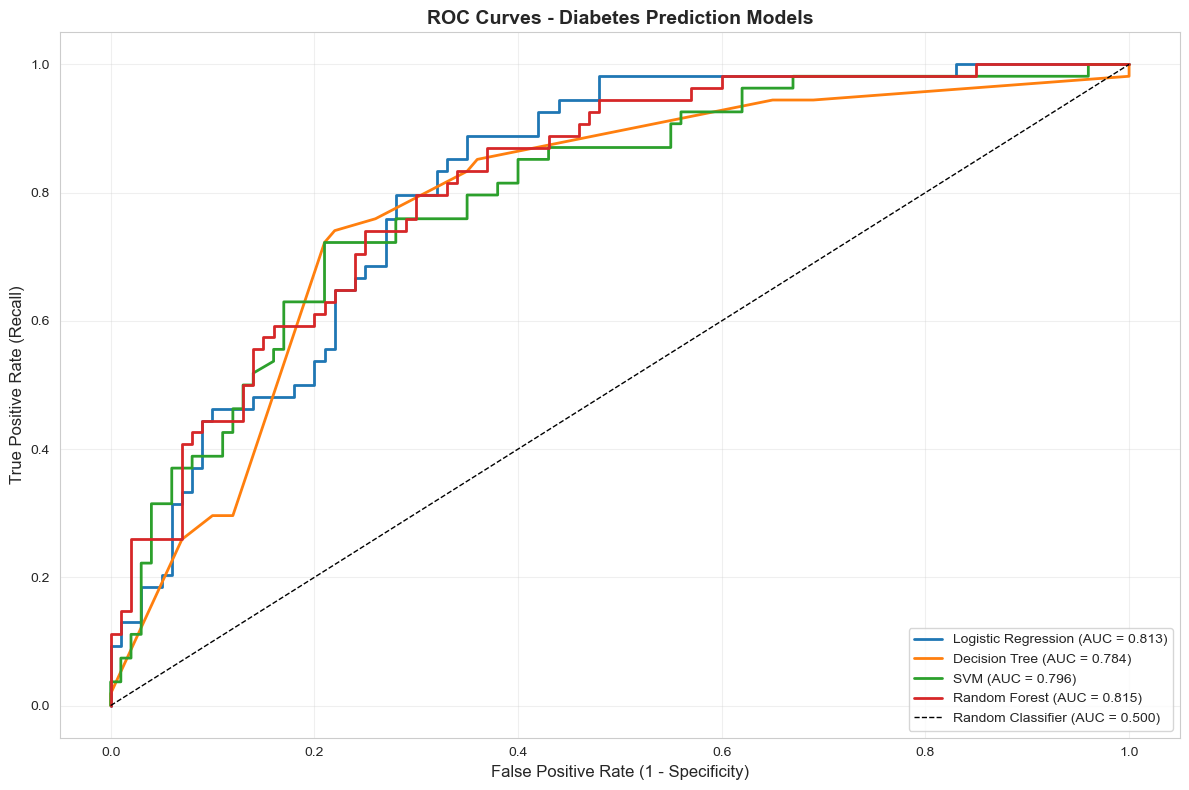

In [76]:
# ============================================
# STEP 4: PLOT ROC CURVES
# ============================================

plt.figure(figsize=(12, 8))

# Plot each model's ROC curve
plt.plot(fpr_lr, tpr_lr, linewidth=2, label=f'Logistic Regression (AUC = {lr_auc:.3f})')
plt.plot(fpr_dt, tpr_dt, linewidth=2, label=f'Decision Tree (AUC = {dt_auc:.3f})')
plt.plot(fpr_svm, tpr_svm, linewidth=2, label=f'SVM (AUC = {svm_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, linewidth=2, label=f'Random Forest (AUC = {rf_auc:.3f})')

# Diagonal line
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

# Labels and title
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall)', fontsize=12)
plt.title('ROC Curves - Diabetes Prediction Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [77]:
# After running the ROC code, print your AUC scores
print("="*60)
print("📊 AUC SCORES FOR ALL MODELS")
print("="*60)

auc_scores = {
    'Logistic Regression': lr_auc,
    'Decision Tree': dt_auc,
    'SVM': svm_auc,
    'Random Forest': rf_auc
}

# Sort by score
sorted_auc = sorted(auc_scores.items(), key=lambda x: x[1], reverse=True)

for i, (model, score) in enumerate(sorted_auc, 1):
    medal = "🥇" if i == 1 else "🥈" if i == 2 else "🥉" if i == 3 else "  "
    print(f"{medal} Rank {i}: {model:20} AUC = {score:.4f}")

📊 AUC SCORES FOR ALL MODELS
🥇 Rank 1: Random Forest        AUC = 0.8148
🥈 Rank 2: Logistic Regression  AUC = 0.8128
🥉 Rank 3: SVM                  AUC = 0.7963
   Rank 4: Decision Tree        AUC = 0.7840


In [79]:
print("\n" + "="*60)
print("📋 AUC INTERPRETATION GUIDE")
print("="*60)

print("""
AUC RANGE      INTERPRETATION
──────────     ─────────────────────────────────────────────
0.90 - 1.00    ★ EXCELLENT - Model almost perfectly separates
               diabetic from non-diabetic patients

0.80 - 0.89    ✓ GOOD - Model clearly distinguishes groups
               with few mistakes

0.70 - 0.79    👌 FAIR - Model useful but has noticeable errors
               (This is where most medical models fall)

0.60 - 0.69    ⚠️ POOR - Model barely better than random
               Not reliable for medical use

0.50 - 0.59    ❌ VERY POOR - Almost random guessing
               Useless for diagnosis

Below 0.50     🚫 WORSE THAN RANDOM - Model actively wrong
               (flip the predictions!)
""")


📋 AUC INTERPRETATION GUIDE

AUC RANGE      INTERPRETATION
──────────     ─────────────────────────────────────────────
0.90 - 1.00    ★ EXCELLENT - Model almost perfectly separates
               diabetic from non-diabetic patients

0.80 - 0.89    ✓ GOOD - Model clearly distinguishes groups
               with few mistakes

0.70 - 0.79    👌 FAIR - Model useful but has noticeable errors
               (This is where most medical models fall)

0.60 - 0.69    ⚠️ POOR - Model barely better than random
               Not reliable for medical use

0.50 - 0.59    ❌ VERY POOR - Almost random guessing
               Useless for diagnosis

Below 0.50     🚫 WORSE THAN RANDOM - Model actively wrong
               (flip the predictions!)



In [ ]:
#Feature Importance (for Random Forest)

